 # 🧠 Smart Loan Approval — Complete Project



 EDA → Preprocessing → Modeling → Tuning → Explainability → Production-ready model



 This notebook is refactored to match the frontend API: only the features that the user will provide are used.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier

import joblib

sns.set_theme(style="whitegrid")
%matplotlib inline


 ## 1️⃣ Load Dataset & Initial Inspection

In [2]:
PATH = '../data/loan_approval_dataset.csv'
TARGET = 'loan_status'

df = pd.read_csv(PATH)
print("Dataset shape:", df.shape)
display(df.head())

print("\n=== Data Info ===")
df.info()

print("\n=== Missing Values ===")
display(df.isna().sum())

print("\n=== Numeric Statistics ===")
display(df.describe())


Dataset shape: (4269, 13)


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected



=== Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB

=== Missin

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64


=== Numeric Statistics ===


,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


 ## 2️⃣ Select API Features Only



 We only keep the features that the frontend will provide:



 - `applicant_income`

 - `loan_amount`

 - `credit_history`

 - `property_area`

 - `education`

 - `self_employed`

In [3]:
API_FEATURES = ['income_annum', 'loan_amount', 'cibil_score', 'education', 'self_employed']

df_api = df[API_FEATURES + [TARGET]]


 ## 3️⃣ EDA - Numeric & Categorical Features

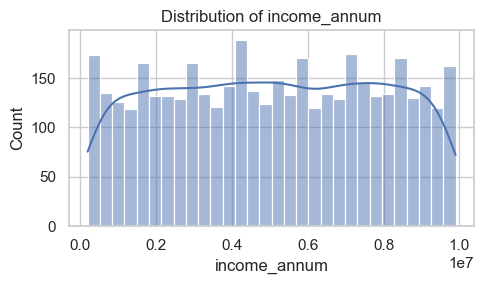

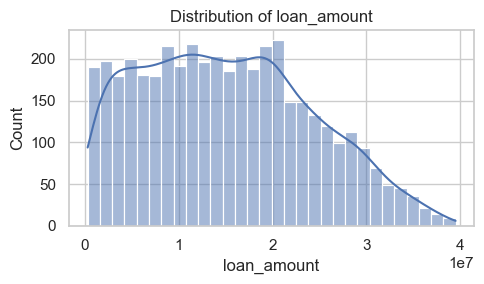

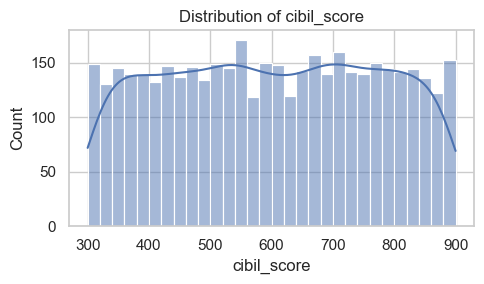

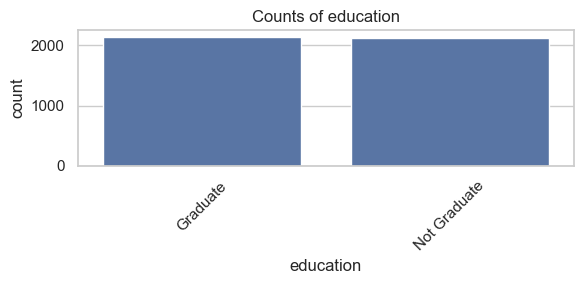

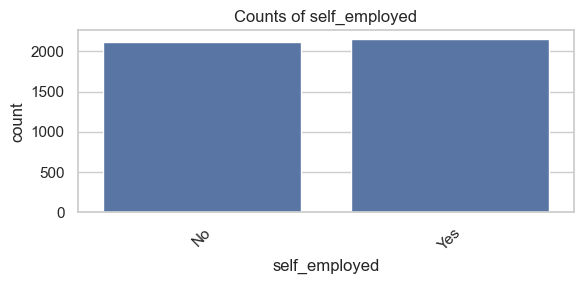

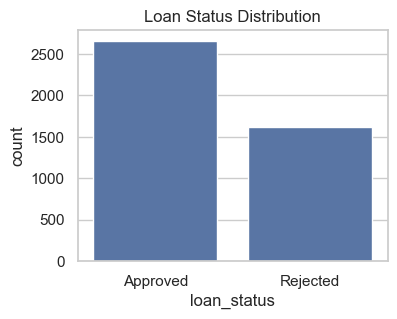

loan_status
Approved    0.62216
Rejected    0.37784
Name: proportion, dtype: float64


In [4]:
numeric_cols = ['income_annum', 'loan_amount', 'cibil_score']
categorical_cols = ['education', 'self_employed']

# Numeric distributions
for col in numeric_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(df_api[col], bins=30, kde=True)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

# Categorical distributions
for col in categorical_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(x=df_api[col])
    plt.title(f'Counts of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Target distribution
plt.figure(figsize=(4,3))
sns.countplot(x=df_api[TARGET])
plt.title("Loan Status Distribution")
plt.show()
print(df_api[TARGET].value_counts(normalize=True))


 ## 4️⃣ Train/Test Split & Pipeline

In [5]:
y = df_api[TARGET].map({'Rejected': 0, 'Approved': 1})
X = df_api.drop(columns=[TARGET])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Pipelines
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols),
    ('cat', categorical_pipeline, categorical_cols)
])


 ## 5️⃣ Modeling Pipelines

In [6]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])
lr_pipeline.fit(X_train, y_train)

# Random Forest
rf_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'))
])
rf_pipeline.fit(X_train, y_train)


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


 ## 6️⃣ Evaluation Function

In [7]:
def evaluate_model(model, X, y):
    preds = model.predict(X)
    probs = model.predict_proba(X)[:,1]

    print("Accuracy:", accuracy_score(y, preds))
    print("F1 Score:", f1_score(y, preds))
    print("ROC-AUC:", roc_auc_score(y, probs))
    print("\nClassification Report:\n", classification_report(y, preds))

    cm = confusion_matrix(y, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


=== Logistic Regression ===
Accuracy: 0.9203747072599532
F1 Score: 0.9369202226345084
ROC-AUC: 0.9698623427961729

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.87      0.89       323
           1       0.92      0.95      0.94       531

    accuracy                           0.92       854
   macro avg       0.92      0.91      0.91       854
weighted avg       0.92      0.92      0.92       854



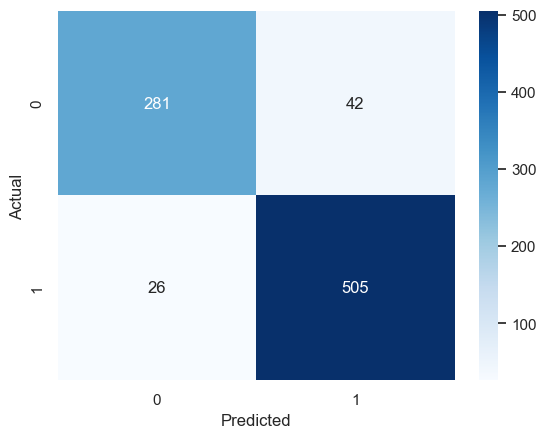

=== Random Forest ===
Accuracy: 0.9660421545667447
F1 Score: 0.9722488038277513
ROC-AUC: 0.9781649204433484

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.98      0.96       323
           1       0.99      0.96      0.97       531

    accuracy                           0.97       854
   macro avg       0.96      0.97      0.96       854
weighted avg       0.97      0.97      0.97       854



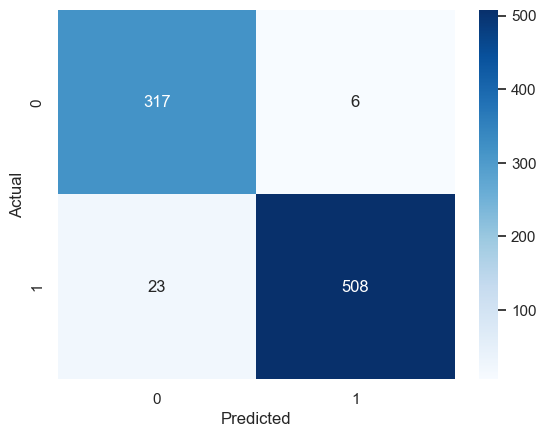

In [8]:
print("=== Logistic Regression ===")
evaluate_model(lr_pipeline, X_test, y_test)

print("=== Random Forest ===")
evaluate_model(rf_pipeline, X_test, y_test)


 ## 7️⃣ Hyperparameter Tuning - Random Forest

In [9]:
param_grid = {
    'model__n_estimators': [200, 300],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5]
}

grid = GridSearchCV(
    rf_pipeline,
    param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
print("Best parameters:", grid.best_params_)


Best parameters: {'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 200}


 ## 8️⃣ Feature Importance

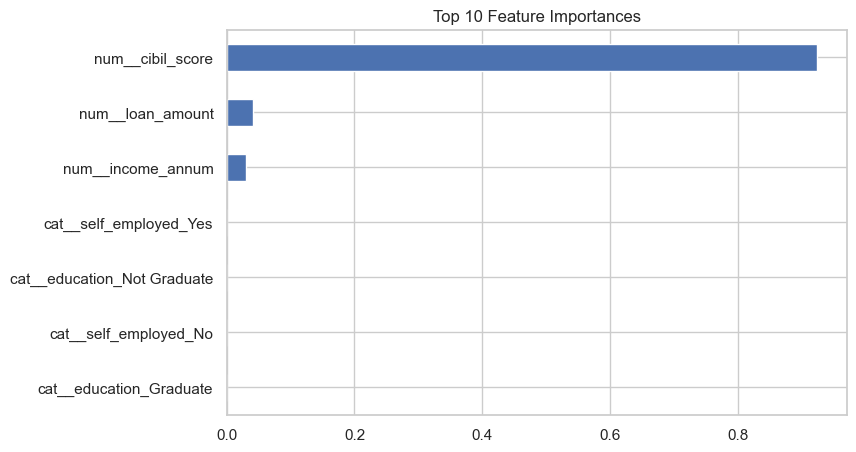

In [10]:
feature_names = best_model.named_steps['preprocess'].get_feature_names_out()
importances = best_model.named_steps['model'].feature_importances_

fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)
plt.figure(figsize=(8,5))
fi.head(10).plot(kind='barh', title='Top 10 Feature Importances')
plt.gca().invert_yaxis()
plt.show()


 ## 9️⃣ Threshold Optimization

              precision    recall  f1-score   support

           0       0.93      0.98      0.96       323
           1       0.99      0.95      0.97       531

    accuracy                           0.97       854
   macro avg       0.96      0.97      0.96       854
weighted avg       0.97      0.97      0.97       854

ROC-AUC: 0.9787829493974218


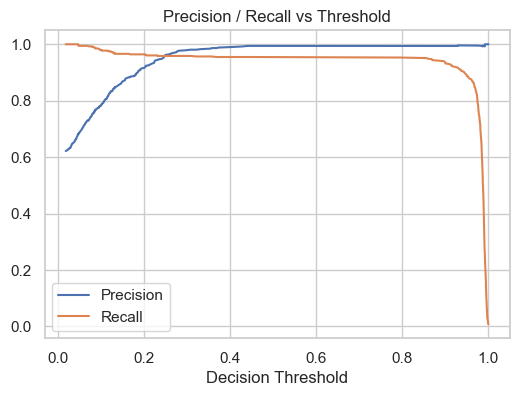

In [11]:
probs = best_model.predict_proba(X_test)[:,1]
precision, recall, thresholds = precision_recall_curve(y_test, probs)

custom_threshold = 0.4
custom_preds = (probs >= custom_threshold).astype(int)

print(classification_report(y_test, custom_preds))
print("ROC-AUC:", roc_auc_score(y_test, probs))

plt.figure(figsize=(6,4))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Decision Threshold')
plt.legend()
plt.title('Precision / Recall vs Threshold')
plt.show()


 ## 10️⃣ Save Final Pipeline for API

In [12]:
joblib.dump(best_model, '../models/loan_approval_pipeline_api.pkl')
print("API-ready pipeline saved successfully!")


API-ready pipeline saved successfully!
